<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
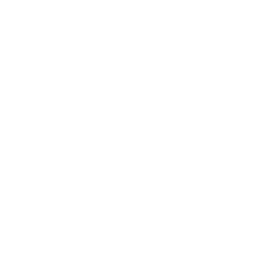
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Utilización de Recursos por Departamento Hospitalario — Gráfico de Barras Horizontales</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Salud / Operaciones Hospitalarias &nbsp;|&nbsp; Marzo de 2026</p>
</div>
</div>
</div>

## Resumen Ejecutivo

Este ejemplo usa gráficos de barras horizontales (HBAR) de **PROC GCHART** para perfilar las horas de personal en seis departamentos clínicos durante el T1 de 2026. Un registro sintético de personal con **90 registros de turno** (15 por departamento) alimenta tres vistas: un gráfico de barras de horas totales clasificado, la duración media del turno por departamento, y HBAR agrupados que dividen cada departamento por categoría de recurso y por turno. `SUMVAR=` acumula las horas laborales reales en lugar de contar registros, `TYPE=SUM`/`TYPE=MEAN` cambian el estadístico de respuesta, `DESCENDING` clasifica los departamentos, y `GROUP=` dibuja barras agrupadas adyacentes para una segunda dimensión.

El resultado respalda la revisión trimestral de eficiencia operativa: revela qué departamentos consumen más horas laborales, cuáles tienen los turnos más largos, y cómo el patrón de personal de día/tarde/noche difiere entre las unidades de agudeza continua y los servicios orientados al horario diurno.

## Fuentes de Datos

| Fuente | Descripción | Registros |
|--------|-------------|--------|
| WORK.STAFFING_LOG | Registros individuales de turno con horas trabajadas | 90 |
| WORK.DEPT_SUMMARY | Totales por departamento y duración media del turno | 6 |

---

In [1]:
/* --------------------------------------------------------
   Genera un registro laboral sintético de personal hospitalario.
   T1 2026: 6 departamentos clínicos, 4 categorías de recurso,
   3 turnos. Dimensionado a 15 registros de turno por departamento
   (90 en total) para que se vea el listado completo de departamentos.
   -------------------------------------------------------- */
DATOS work.staffing_log;
    LLAMAR streaminit(20260601);
    LONGITUD department $20 resource_type $20 shift $6;

    /* mezcla de categoría de recurso (dotación clínica con predominio de enfermería) */
    ARREGLO resw[4] _temporary_ (0.50 0.20 0.20 0.10);

    /* mezcla base de turnos, inclinada hacia Noche para unidades de 24/7 */
    ARREGLO shfw[3] _temporary_ (0.45 0.30 0.25);
    ARREGLO nightlift[6] _temporary_
        (0.18 0.00 0.22 -0.05 -0.05 0.05);

    HACER di = 1 HASTA 6;
        SI di = 1 ENTONCES department = 'Emergencias';
        SINO SI di = 2 ENTONCES department = 'Cirugía';
        SINO SI di = 3 ENTONCES department = 'UCI';
        SINO SI di = 4 ENTONCES department = 'Pediatría';
        SINO SI di = 5 ENTONCES department = 'Oncología';
        SINO department = 'Maternidad';
        HACER rec = 1 HASTA 15;

            /* categoría de recurso mediante sorteo ponderado */
            u = rand('uniform'); cum = 0;
            HACER r = 1 HASTA 4;
                cum + resw[r];
                SI u <= cum ENTONCES HACER;
                    SI r = 1 ENTONCES resource_type = 'Enfermería';
                    SINO SI r = 2 ENTONCES resource_type = 'Médico';
                    SINO SI r = 3 ENTONCES resource_type = 'Personal Auxiliar';
                    SINO resource_type = 'Apoyo';
                    SALIR;
                END;
            END;

            /* turno según la inclinación nocturna propia del departamento */
            w1 = shfw[1] - nightlift[di] / 2;
            w2 = shfw[2] - nightlift[di] / 2;
            u = rand('uniform');
            SI u <= w1 ENTONCES shift = 'Día';
            SINO SI u <= w1 + w2 ENTONCES shift = 'Tarde';
            SINO shift = 'Noche';

            /* horas: médicos y cirugía tienen turnos más largos */
            BASE = 8;
            SI resource_type = 'Médico' ENTONCES BASE = BASE + 1.5;
            SI department = 'Cirugía'      ENTONCES BASE = BASE + 1.0;
            hours_worked = round(BASE + rand('normal', 0, 0.8), 0.25);
            SI hours_worked < 4 ENTONCES hours_worked = 4;

            SALIDA;
        END;
    END;
    MANTENER department resource_type shift hours_worked;
EJECUTAR;


NOTE: DATA work.staffing_log


NOTE: Wrote work.staffing_log (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Totales por departamento y duración media del turno,
   clasificados por horas laborales totales.
   -------------------------------------------------------- */
PROCEDIMIENTO SQL;
    CREAR TABLA work.dept_summary AS
    SELECCIONAR department,
           sum(hours_worked)  AS total_hours   FORMATO=8.2,
           count(*)           AS shift_count,
           mean(hours_worked) AS avg_shift_hrs  FORMATO=6.2
    DESDE work.staffing_log
    GROUP POR department
    ORDER POR total_hours DESC;
QUIT;

PROCEDIMIENTO IMPRIMIR DATOS=work.dept_summary noobs ETIQUETA;
    ETIQUETA department    = 'Departamento'
          total_hours   = 'Horas Totales'
          shift_count   = 'Turnos'
          avg_shift_hrs = 'Turno Medio (hrs)';
    TÍTULO 'Resumen de Horas Laborales por Departamento - T1 2026';
EJECUTAR;
TÍTULO;

                                 Resumen de Horas Laborales por Departamento - T1 2026                                  

Departamento  Horas Totales  Turnos  Turno Medio (hrs)
Cirugía              136.25      15               9.08
UCI                  128.50      15               8.57
Maternidad           127.75      15               8.52
Pediatría            124.75      15               8.32
Oncología            123.75      15               8.25
Emergencias          119.25      15               7.95




NOTE: PROC SQL 

NOTE: Table work.dept_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.dept_summary

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

                                            Horas Laborales por Departamento                                            

                                                  The MEANS Procedure

                                   Analysis Variable : hours_worked Horas Trabajadas

        Departamento            Sum           Mean          N Obs
        ---------------------------------------------------------
        Cirugía              136.25           9.08             15
        Emergencias          119.25           7.95             15
        Maternidad           127.75           8.52             15
        Oncología            123.75           8.25             15
        Pediatría            124.75           8.32             15
        UCI                  128.50           8.57             15
        ---------------------------------------------------------

                                        Distribución de Turnos por Departamento                                         

    


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_shift.spec.json
NOTE: PROC FREQ statement used.


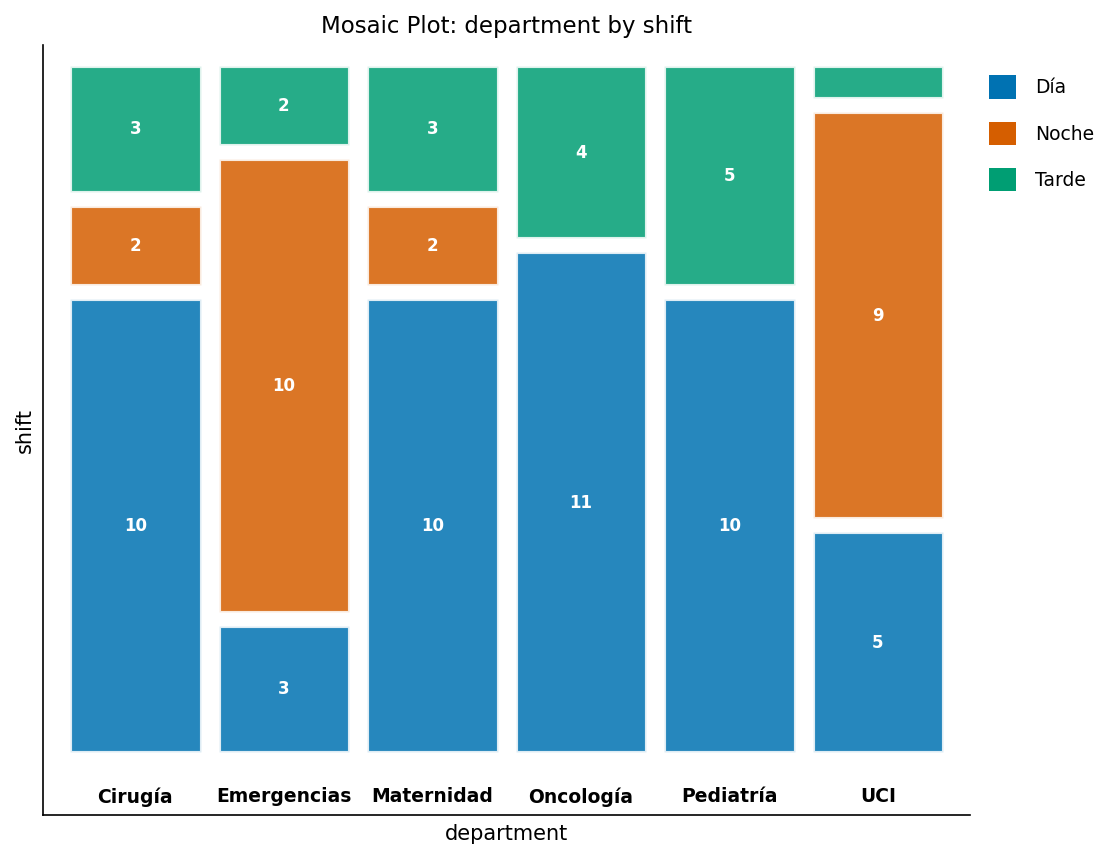

In [3]:
/* --------------------------------------------------------
   Tablas base: horas laborales por departamento, y la
   distribución de turnos día / tarde / noche por departamento.
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.staffing_log sum mean n maxdec=2;
    CLASE department;
    VAR hours_worked;
    ETIQUETA department = 'Departamento' hours_worked = 'Horas Trabajadas';
    TÍTULO 'Horas Laborales por Departamento';
EJECUTAR;

PROCEDIMIENTO FRECUENCIAS DATOS=work.staffing_log;
    TABLES department * shift / norow nocol nopercent;
    ETIQUETA department = 'Departamento' shift = 'Turno';
    TÍTULO 'Distribución de Turnos por Departamento';
EJECUTAR;
TÍTULO;

---


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


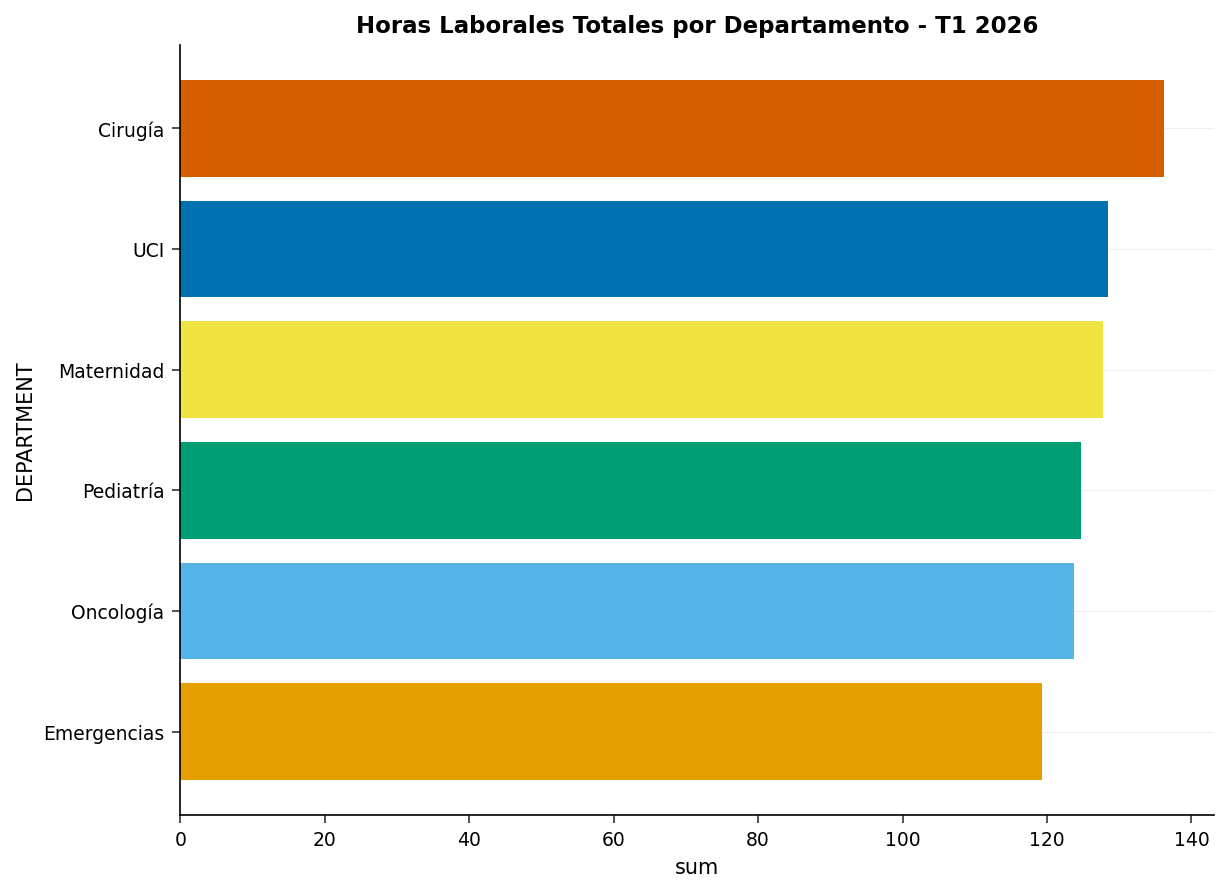

In [4]:
/* --------------------------------------------------------
   HBAR general: horas laborales totales por departamento.
   SUMVAR= acumula horas; DESCENDENTE clasifica las barras.
   -------------------------------------------------------- */
PROCEDIMIENTO GCHART DATOS=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=sum
                      DESCENDENTE;
    ETIQUETA department = 'Departamento' hours_worked = 'Horas Trabajadas';
    TÍTULO 'Horas Laborales Totales por Departamento - T1 2026';
EJECUTAR;
QUIT;
TÍTULO;

### División de cada departamento por categoría de recurso

`GROUP=` dibuja un grupo de barras horizontales adyacentes para cada departamento, una barra por categoría de recurso. Debido a que `SUMVAR=hours_worked` está vigente, cada barra mide las horas laborales acumuladas en lugar de un conteo de registros, por lo que el gráfico muestra cómo se comparan las horas de enfermería, médicas, de personal auxiliar y de apoyo *dentro* de cada departamento.

In [5]:
/* --------------------------------------------------------
   Sentencias PATTERN: paleta coordinada de 4 colores,
   un patrón por subgrupo de categoría de recurso
   -------------------------------------------------------- */
pattern1 VALUE=solid color=cx2C5F8A;   /* Enfermería - azul oscuro   */
pattern2 VALUE=solid color=cx28A745;   /* Médico - verde            */
pattern3 VALUE=solid color=cxE8650A;   /* Personal Auxiliar - ámbar */
pattern4 VALUE=solid color=cx6C757D;   /* Personal de Apoyo - gris  */

                               Horas Laborales del Departamento por Categoría de Recurso                                


Fuente: Sistema de Gestión de Personal | Período del informe: Ene-Mar 2026



NOTE: Option TITLE changed to Horas Laborales del Departamento por Categoría de Recurso.
NOTE: Option FOOTNOTE changed to Fuente: Sistema de Gestión de Personal | Período del informe: Ene-Mar 2026.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


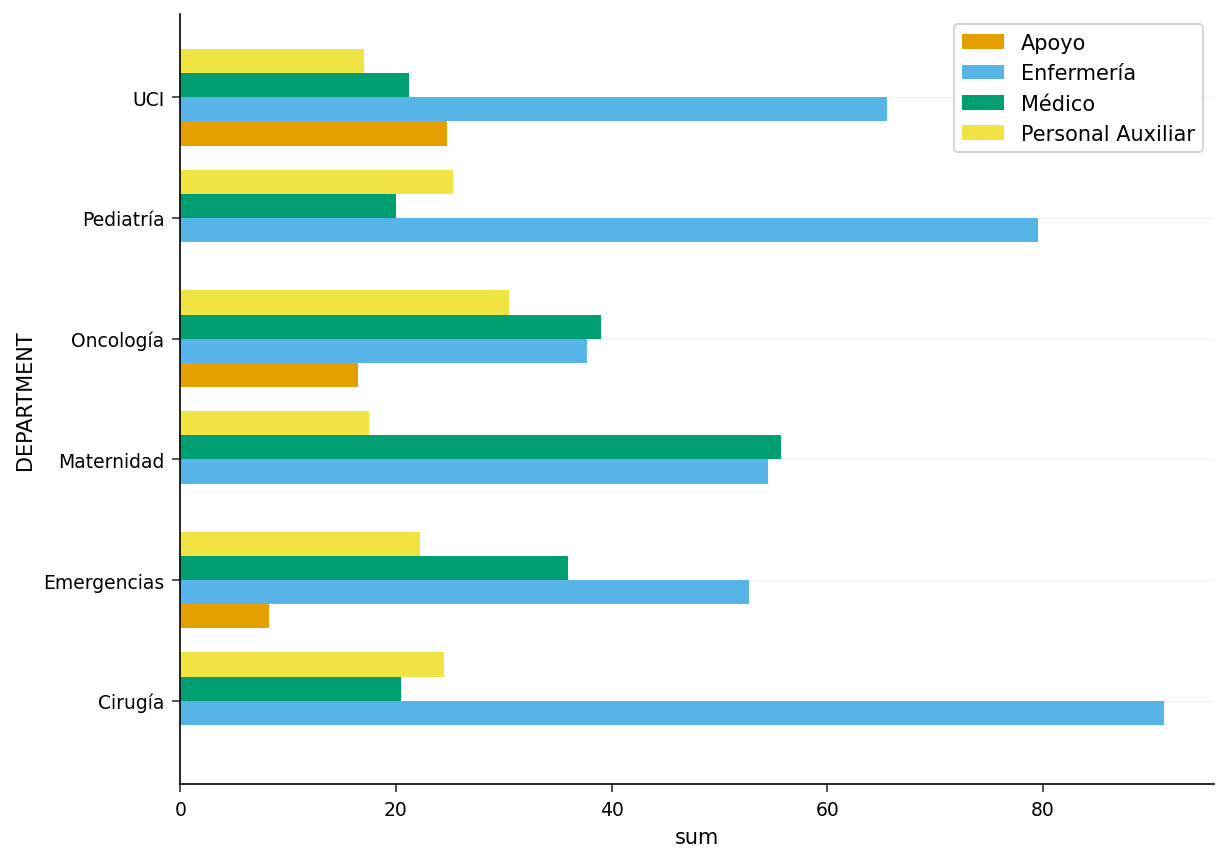

In [6]:
/* --------------------------------------------------------
   HBAR agrupado por categoría de recurso (GROUP=).
   Cada departamento se convierte en un grupo de barras -- una
   por categoría de recurso -- medidas en horas laborales acumuladas.
   -------------------------------------------------------- */
TÍTULO 'Horas Laborales del Departamento por Categoría de Recurso';
footnote JUSTIFY=LEFT
    'Fuente: Sistema de Gestión de Personal | Período del informe: Ene-Mar 2026';

PROCEDIMIENTO GCHART DATOS=work.staffing_log;
    HBAR department / GROUP=resource_type
                      SUMVAR=hours_worked
                      type=sum;
    ETIQUETA department = 'Departamento' resource_type = 'Categoría de Recurso' hours_worked = 'Horas Trabajadas';
EJECUTAR;
QUIT;

TÍTULO; footnote;

                                       Horas Laborales del Departamento por Turno                                       


Las barras agrupadas separan las contribuciones de Día / Tarde / Noche por departamento



NOTE: Option TITLE changed to Horas Laborales del Departamento por Turno.
NOTE: Option FOOTNOTE changed to Las barras agrupadas separan las contribuciones de Día / Tarde / Noche por departamento.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


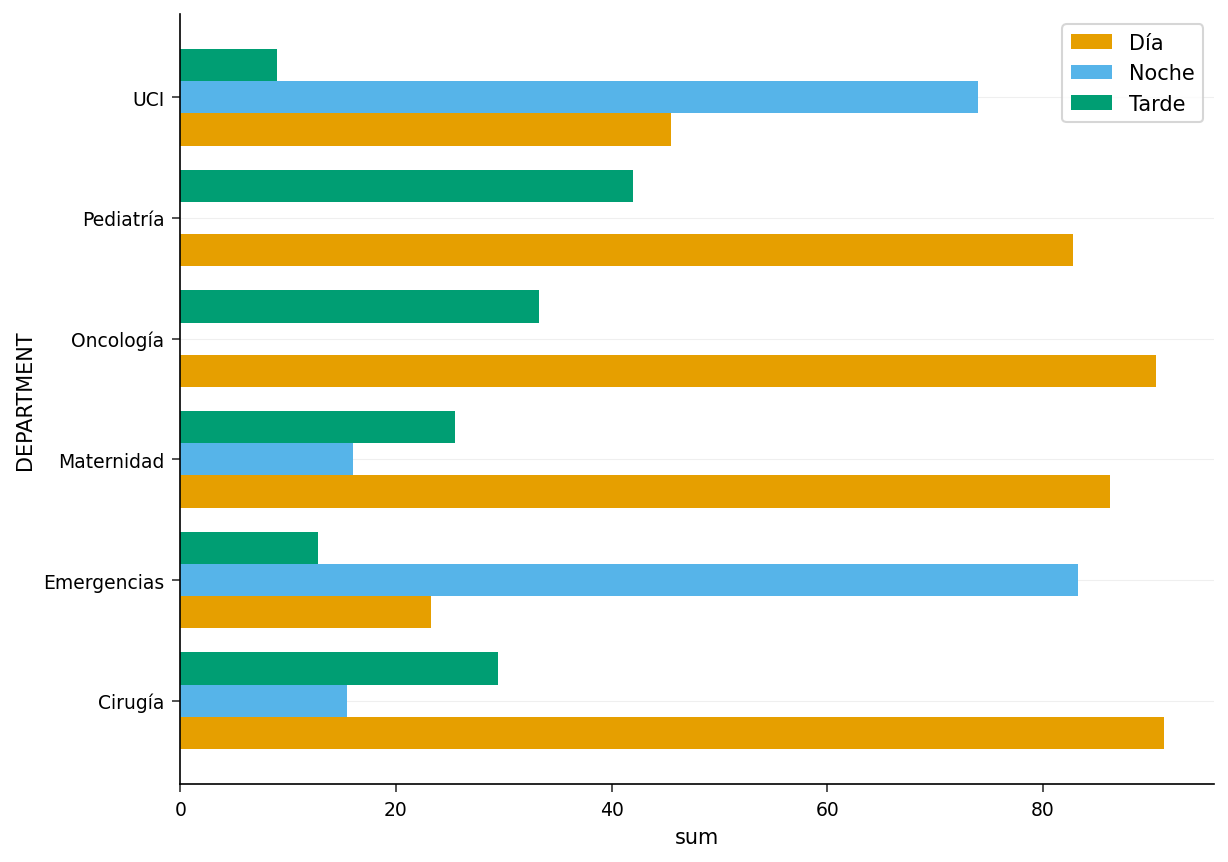

In [7]:
/* --------------------------------------------------------
   HBAR agrupado por turno (GROUP=).
   Separa las horas laborales de Día / Tarde / Noche dentro
   de cada departamento -- destacando las unidades de 24/7.
   -------------------------------------------------------- */
TÍTULO 'Horas Laborales del Departamento por Turno';
footnote JUSTIFY=LEFT
    'Las barras agrupadas separan las contribuciones de Día / Tarde / Noche por departamento';

PROCEDIMIENTO GCHART DATOS=work.staffing_log;
    HBAR department / GROUP=shift
                      SUMVAR=hours_worked
                      type=sum;
    ETIQUETA department = 'Departamento' shift = 'Turno' hours_worked = 'Horas Trabajadas';
EJECUTAR;
QUIT;

TÍTULO; footnote;


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


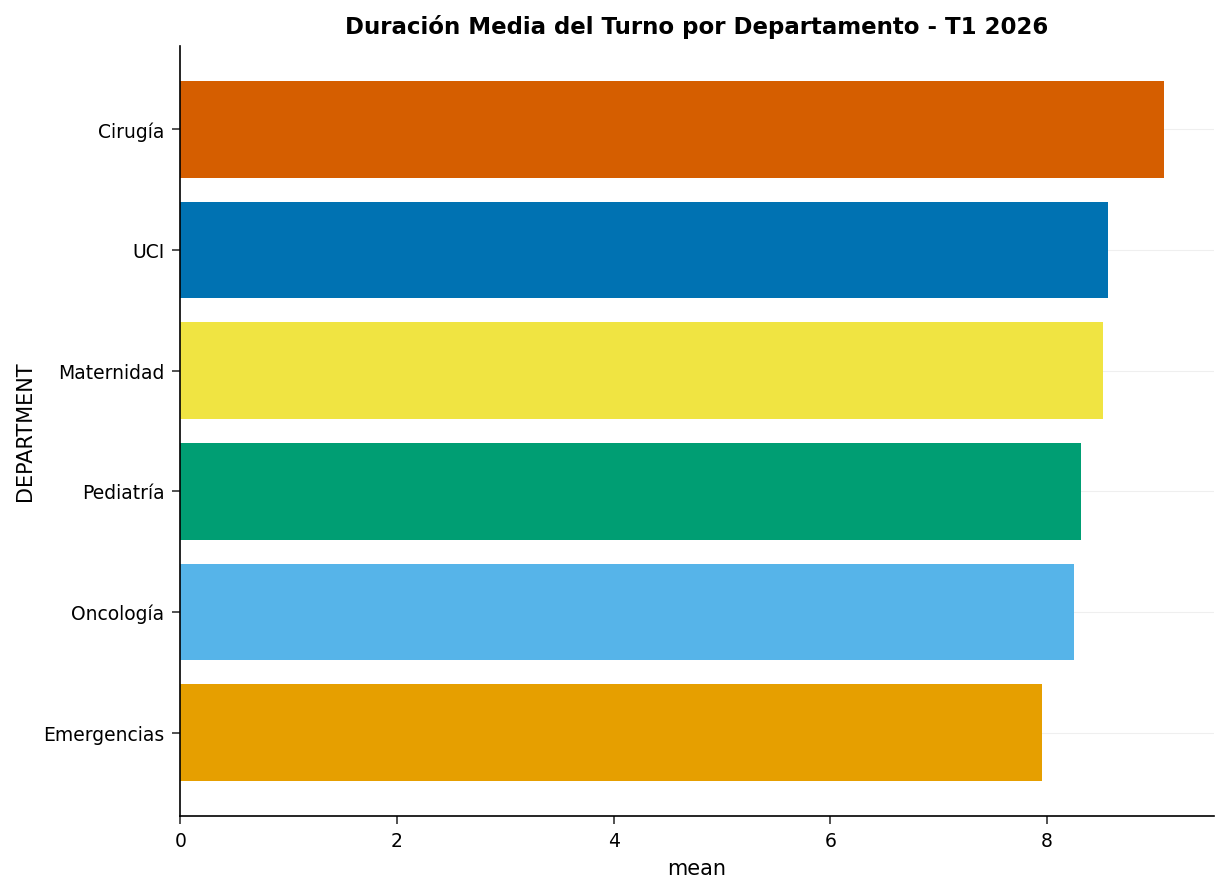

In [8]:
/* --------------------------------------------------------
   Duración media del turno por departamento (TYPE=MEAN).
   Revela si un departamento tiene turnos largos o muchos
   turnos cortos, independientemente del volumen total.
   -------------------------------------------------------- */
PROCEDIMIENTO GCHART DATOS=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=mean
                      DESCENDENTE;
    ETIQUETA department = 'Departamento' hours_worked = 'Horas Trabajadas';
    TÍTULO 'Duración Media del Turno por Departamento - T1 2026';
EJECUTAR;
QUIT;
TÍTULO;

---

### Interpretación

En los 90 registros de turno, las horas laborales totales se mueven en una banda estrecha entre **119.25** (Emergencias) y **136.25** (Cirugía), porque cada departamento tiene los mismos 15 turnos en este período — por lo que la clasificación refleja la **duración del turno**, no el número de turnos. Cirugía encabeza tanto el gráfico de horas totales como el de turno medio con **9.08 horas** por turno, en consonancia con casos quirúrgicos más largos y la dotación con predominio médico que estos casos requieren. Emergencias se ubica al final en horas (media de **7.95**) a pesar de ser una de las unidades más ocupadas, porque su trabajo se realiza en turnos más cortos y de mayor rotación.

El HBAR agrupado por turno y el panel de mosaico cuentan la historia operativamente importante. **Emergencias y UCI están dominadas por la noche** — 10 de 15 y 9 de 15 turnos, respectivamente, caen en Noche — mientras que **Oncología y Pediatría no registran ningún turno de Noche** y se concentran en la cobertura de Día (11 y 10 turnos de Día). Esa división refleja la dotación hospitalaria real: las unidades de agudeza continua funcionan las 24 horas, mientras que la infusión oncológica y la pediatría general son servicios diurnos. El panel de categoría de recurso confirma una **mezcla liderada por enfermería** en cada departamento, con las horas médicas y de personal auxiliar formando los niveles secundarios.

Para la revisión de personal del T2, la concentración de turnos nocturnos en Emergencias y UCI es la partida a vigilar: es donde se acumulan los costos de tarifa premium y gestión de la fatiga, y donde cualquier cambio en la rotación tiene el mayor impacto presupuestario.

---

In [9]:
/* --------------------------------------------------------
   Exportar el resumen por departamento para el sistema
   de planificación de personal.
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.dept_summary
    OUTFILE='q1_dept_labor_summary.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=work.dept_summary outfile=q1_dept_labor_summary.csv

NOTE: Exported 6 rows to q1_dept_labor_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Con la tecnología de <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>